In [4]:
import numpy as np

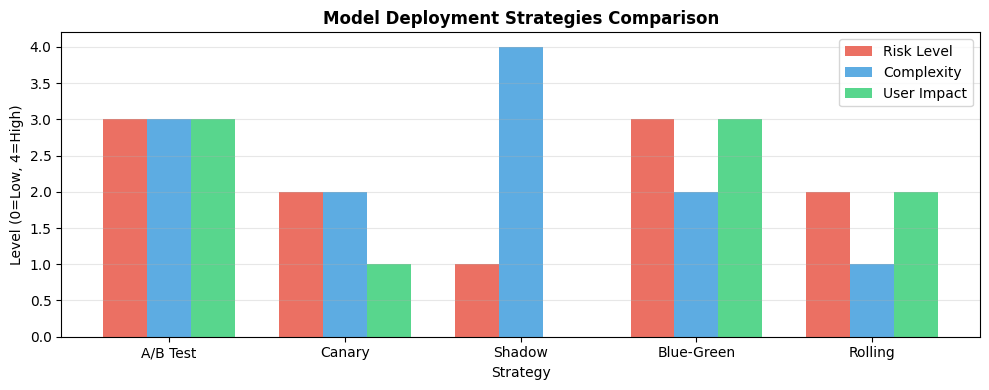

In [5]:
# ──────────────────────────────────────────────
# Deployment Strategies Comparison
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

strategies = ['A/B Test', 'Canary', 'Shadow', 'Blue-Green', 'Rolling']
risk = [3, 2, 1, 3, 2]
complexity = [3, 2, 4, 2, 1]
user_impact = [3, 1, 0, 3, 2]

x = np.arange(len(strategies))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width, risk, width, label='Risk Level', color='#e74c3c', alpha=0.8)
ax.bar(x, complexity, width, label='Complexity', color='#3498db', alpha=0.8)
ax.bar(x + width, user_impact, width, label='User Impact', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Strategy')
ax.set_ylabel('Level (0=Low, 4=High)')
ax.set_title('Model Deployment Strategies Comparison', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---

#### Environment Setup (Google Colab / Local)

In [6]:
# ──────────────────────────────────────────────
# Install required packages (run once)
# ──────────────────────────────────────────────
# !pip install -q flask fastapi uvicorn mlflow wandb
# !pip install -q evidently alibi-detect
# !pip install -q scikit-learn pandas numpy joblib
# !pip install -q docker  # for Docker SDK

In [7]:
# ──────────────────────────────────────────────
# Core Imports
# ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import json, os, time
print("Core imports loaded")

Core imports loaded


---

<a id="mlops-fundamentals"></a>

### Part 1: MLOps Fundamentals

#### ML Lifecycle Stages

| Stage | Activities | Tools |
| --- | --- | --- |
| **Data** | Collect, clean, version, label | DVC, Airflow, LabelStudio |
| **Experiment** | Train, evaluate, compare, tune | MLflow, W&B, Optuna |
| **Deploy** | Package, serve, scale | Docker, K8s, TF Serving, Triton |
| **Monitor** | Track drift, performance, alerts | Evidently, Prometheus, Grafana |
| **Retrain** | Trigger retraining on drift | Airflow, Kubeflow, Vertex AI |

#### MLOps Maturity Levels

| Level | Description | Characteristics |
| --- | --- | --- |
| **0 — Manual** | No MLOps | Jupyter notebooks, manual deploy, no versioning |
| **1 — DevOps** | Basic automation | CI/CD, Docker, basic monitoring |
| **2 — ML Pipeline** | Automated training | Orchestrated pipelines, feature stores |
| **3 — Full MLOps** | Automated everything | Auto retraining, A/B testing, drift detection |

#### Data/Model Versioning

| Tool | Type | Key Feature |
| --- | --- | --- |
| **DVC** | Data versioning | Git-like commands for data and models |
| **MLflow** | Experiment tracking | Parameters, metrics, artifacts, model registry |
| **W&B** | Experiment tracking | Cloud UI, sweeps, artifact management |
| **Git LFS** | Large file storage | Store large files in Git repos |

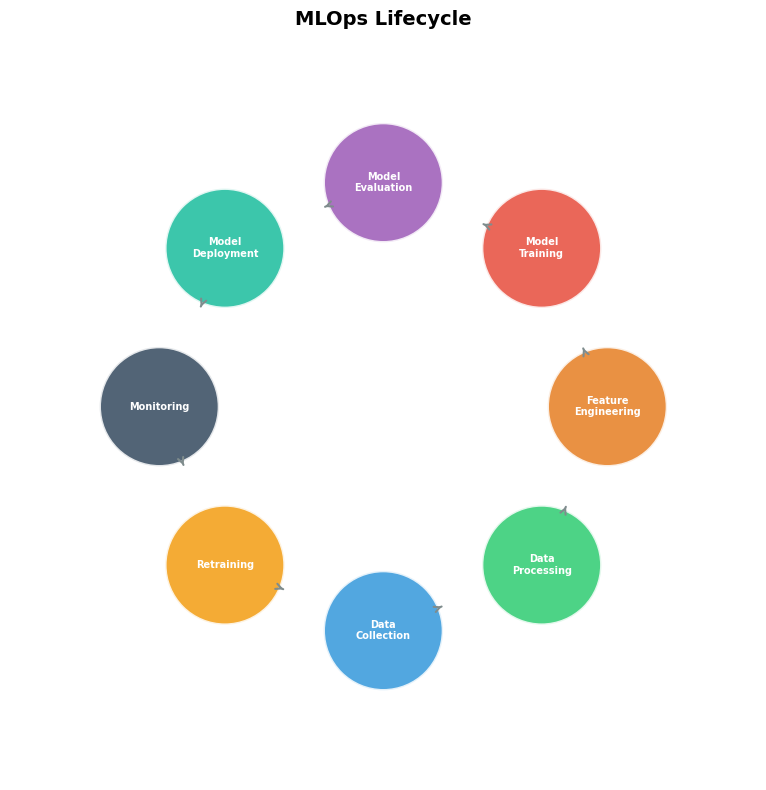

In [8]:
# ──────────────────────────────────────────────
# MLOps Lifecycle Visualization
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 8))

stages = ['Data\nCollection', 'Data\nProcessing', 'Feature\nEngineering',
          'Model\nTraining', 'Model\nEvaluation', 'Model\nDeployment',
          'Monitoring', 'Retraining']
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c',
          '#9b59b6', '#1abc9c', '#34495e', '#f39c12']

n = len(stages)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
radius = 3

for i, (stage, color, angle) in enumerate(zip(stages, colors, angles)):
    x = radius * np.cos(angle - np.pi/2)
    y = radius * np.sin(angle - np.pi/2)
    circle = plt.Circle((x, y), 0.8, facecolor=color, edgecolor='white', linewidth=2, alpha=0.85)
    ax.add_patch(circle)
    ax.text(x, y, stage, ha='center', va='center', fontsize=7, fontweight='bold', color='white')
    
    # Arrow to next stage
    next_i = (i + 1) % n
    x2 = radius * np.cos(angles[next_i] - np.pi/2)
    y2 = radius * np.sin(angles[next_i] - np.pi/2)
    dx, dy = x2 - x, y2 - y
    dist = np.sqrt(dx**2 + dy**2)
    ax.annotate('', xy=(x + 0.85*dx/dist, y + 0.85*dy/dist),
                xytext=(x + 0.85*(dx/dist)*0.95, y + 0.85*(dy/dist)*0.95),
                arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('MLOps Lifecycle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

<a id="docker"></a>

### Part 2: Docker — Containerization for ML

#### Docker Key Concepts

| Concept | Description |
| --- | --- |
| **Image** | Read-only template with application + dependencies |
| **Container** | Running instance of an image (isolated process) |
| **Dockerfile** | Instructions to build an image |
| **Registry** | Store for images (Docker Hub, ECR, GCR) |
| **Volume** | Persistent storage mounted into container |
| **Network** | Container communication (bridge, host, overlay) |
| **Docker Compose** | Multi-container applications defined in YAML |

#### Dockerfile Best Practices for ML

| Practice | Description |
| --- | --- |
| **Multi-stage builds** | Separate build from runtime (smaller final image) |
| **Layer caching** | Put rarely-changing instructions first (requirements before code) |
| **Slim base images** | Use python:3.10-slim instead of python:3.10 |
| **Non-root user** | Run as non-root for security |
| **.dockerignore** | Exclude .git, data, __pycache__, .env |

In [9]:
# ──────────────────────────────────────────────
# Dockerfile for ML Model Serving
# ──────────────────────────────────────────────
dockerfile_content = '''
# Multi-stage build for ML model serving
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Runtime stage
FROM python:3.10-slim

WORKDIR /app
COPY --from=builder /usr/local/lib/python3.10/site-packages /usr/local/lib/python3.10/site-packages
COPY --from=builder /usr/local/bin /usr/local/bin

# Copy model and application code
COPY model/ ./model/
COPY app.py .

# Create non-root user
RUN useradd -m appuser
USER appuser

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

print("Dockerfile for ML Model Serving:")
print(dockerfile_content)

# Docker Compose for ML system
compose_content = '''
version: "3.8"
services:
  model-api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    environment:
      - MODEL_PATH=/app/models/model.pkl
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      retries: 3
  
  prometheus:
    image: prom/prometheus
    ports:
      - "9090:9090"
    volumes:
      - ./prometheus.yml:/etc/prometheus/prometheus.yml
  
  grafana:
    image: grafana/grafana
    ports:
      - "3000:3000"
'''

print("Docker Compose for ML System:")
print(compose_content)

Dockerfile for ML Model Serving:

# Multi-stage build for ML model serving
FROM python:3.10-slim AS builder

WORKDIR /app
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Runtime stage
FROM python:3.10-slim

WORKDIR /app
COPY --from=builder /usr/local/lib/python3.10/site-packages /usr/local/lib/python3.10/site-packages
COPY --from=builder /usr/local/bin /usr/local/bin

# Copy model and application code
COPY model/ ./model/
COPY app.py .

# Create non-root user
RUN useradd -m appuser
USER appuser

EXPOSE 8000
CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Docker Compose for ML System:

version: "3.8"
services:
  model-api:
    build: .
    ports:
      - "8000:8000"
    volumes:
      - ./models:/app/models
    environment:
      - MODEL_PATH=/app/models/model.pkl
    healthcheck:
      test: ["CMD", "curl", "-f", "http://localhost:8000/health"]
      interval: 30s
      retries: 3

  prometheus:
    image: prom/prometheus
    ports:
    

---

<a id="kubernetes"></a>

#### Kubernetes — Container Orchestration

| Concept | Description |
| --- | --- |
| **Pod** | Smallest deployable unit; one or more containers |
| **Deployment** | Manages pod replicas; rolling updates |
| **Service** | Stable network endpoint for pods (ClusterIP, LoadBalancer) |
| **Ingress** | HTTP routing; SSL termination |
| **HPA** | Horizontal Pod Autoscaler (scale based on CPU/custom metrics) |
| **ConfigMap/Secret** | Configuration and sensitive data management |
| **Persistent Volume** | Durable storage for models and data |

#### ML-Specific Kubernetes Tools

| Tool | Purpose |
| --- | --- |
| **Kubeflow** | End-to-end ML platform on K8s (pipelines, training, serving) |
| **Seldon Core** | ML model deployment and management |
| **KServe** | Serverless model inference on K8s |
| **Argo Workflows** | Workflow orchestration for ML pipelines |

---

<a id="cicd"></a>

### Part 3: CI/CD for Machine Learning

#### CI/CD Pipeline Stages for ML

| Stage | Actions | Tools |
| --- | --- | --- |
| **Code Quality** | Lint, type check, format | flake8, mypy, black |
| **Unit Tests** | Test preprocessing, feature engineering | pytest |
| **Integration Tests** | Test model loading, API endpoints | pytest + Docker |
| **Model Validation** | Check accuracy thresholds, performance regression | Custom scripts |
| **Build** | Docker image build | Docker, BuildKit |
| **Push** | Push to registry | ECR, GCR, DockerHub |
| **Deploy** | Deploy to staging/production | K8s, ECS, Cloud Run |
| **Smoke Tests** | Verify deployed model responds correctly | curl, httpx |

#### ML-Specific CI/CD Considerations

| Consideration | Description |
| --- | --- |
| **Data validation** | Check schema, distribution before training |
| **Model performance gates** | Require minimum accuracy/F1 to deploy |
| **Shadow deployment** | Run new model alongside old, compare outputs |
| **Canary deployment** | Route small % of traffic to new model |
| **Rollback** | Automated rollback if performance drops |

---

<a id="model-serving"></a>

### Part 4: Model Serving

#### Serving Frameworks Comparison

| Framework | Type | Protocol | Best For |
| --- | --- | --- | --- |
| **Flask** | REST API | HTTP/JSON | Simple prototypes |
| **FastAPI** | REST API | HTTP/JSON + async | Production APIs |
| **TF Serving** | Model server | gRPC + REST | TensorFlow models |
| **Triton** | Model server | gRPC + REST | Multi-framework (TF, PyTorch, ONNX) |
| **TorchServe** | Model server | gRPC + REST | PyTorch models |
| **BentoML** | Serving framework | HTTP/gRPC | Multi-framework, easy packaging |
| **Ray Serve** | Serving framework | HTTP | Scalable, composable models |

#### Serving Patterns

| Pattern | Description | Use Case |
| --- | --- | --- |
| **Online (real-time)** | Single prediction per request (low latency) | Recommendation, fraud detection |
| **Batch** | Process many predictions at once | Daily scoring, reports |
| **Streaming** | Continuous prediction on data streams | IoT, real-time monitoring |
| **Edge** | Run model on device (ONNX, TFLite) | Mobile, embedded systems |

In [10]:
# ──────────────────────────────────────────────
# FastAPI — ML Model Serving
# ──────────────────────────────────────────────
fastapi_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="ML Model API", version="1.0")

# Load model at startup
model = joblib.load("model.pkl")

class PredictRequest(BaseModel):
    features: list[float]

class PredictResponse(BaseModel):
    prediction: int
    probability: float
    model_version: str = "1.0"

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    try:
        X = np.array(request.features).reshape(1, -1)
        pred = model.predict(X)[0]
        prob = model.predict_proba(X)[0].max()
        return PredictResponse(prediction=int(pred), probability=float(prob))
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.post("/predict_batch")
def predict_batch(requests: list[PredictRequest]):
    X = np.array([r.features for r in requests])
    preds = model.predict(X)
    probs = model.predict_proba(X).max(axis=1)
    return [{"prediction": int(p), "probability": float(pr)} 
            for p, pr in zip(preds, probs)]
'''

print("FastAPI ML Model Serving:")
print(fastapi_code)

FastAPI ML Model Serving:

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

app = FastAPI(title="ML Model API", version="1.0")

# Load model at startup
model = joblib.load("model.pkl")

class PredictRequest(BaseModel):
    features: list[float]

class PredictResponse(BaseModel):
    prediction: int
    probability: float
    model_version: str = "1.0"

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    try:
        X = np.array(request.features).reshape(1, -1)
        pred = model.predict(X)[0]
        prob = model.predict_proba(X)[0].max()
        return PredictResponse(prediction=int(pred), probability=float(prob))
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))

@app.post("/predict_batch")
def predict_batch(requests: list[PredictRequest]):
    X = np.array([r.features for r i

In [11]:
# ──────────────────────────────────────────────
# Model Serialization Comparison
# ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
import joblib
import pickle
import tempfile, os

X, y = load_iris(return_X_y=True)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Method 1: joblib (recommended for sklearn)
path1 = os.path.join(tempfile.gettempdir(), "model_joblib.pkl")
joblib.dump(model, path1)
loaded1 = joblib.load(path1)
print(f"Joblib: {os.path.getsize(path1)/1024:.1f} KB, acc={loaded1.score(X,y):.4f}")

# Method 2: pickle
path2 = os.path.join(tempfile.gettempdir(), "model_pickle.pkl")
with open(path2, 'wb') as f:
    pickle.dump(model, f)
with open(path2, 'rb') as f:
    loaded2 = pickle.load(f)
print(f"Pickle: {os.path.getsize(path2)/1024:.1f} KB, acc={loaded2.score(X,y):.4f}")

# Method 3: ONNX (cross-framework)
print("\nONNX: Convert sklearn/PyTorch/TF to portable format")
print("  pip install skl2onnx onnxruntime")
print("  Benefits: faster inference, framework-agnostic, optimized runtime")

print("\nSerialization Comparison:")
print(f"{'Method':<15} {'Pros':<40} {'Cons':<30}")
print("-" * 85)
print(f"{'joblib':<15} {'Best for sklearn (efficient numpy)':<40} {'Python-only':<30}")
print(f"{'pickle':<15} {'Standard Python':<40} {'Security risk, Python-only':<30}")
print(f"{'ONNX':<15} {'Cross-framework, optimized runtime':<40} {'Conversion needed':<30}")
print(f"{'TorchScript':<15} {'PyTorch production (no Python dep)':<40} {'PyTorch only':<30}")
print(f"{'SavedModel':<15} {'TF standard (TF Serving)':<40} {'TF only':<30}")

Joblib: 182.4 KB, acc=1.0000
Pickle: 172.9 KB, acc=1.0000

ONNX: Convert sklearn/PyTorch/TF to portable format
  pip install skl2onnx onnxruntime
  Benefits: faster inference, framework-agnostic, optimized runtime

Serialization Comparison:
Method          Pros                                     Cons                          
-------------------------------------------------------------------------------------
joblib          Best for sklearn (efficient numpy)       Python-only                   
pickle          Standard Python                          Security risk, Python-only    
ONNX            Cross-framework, optimized runtime       Conversion needed             
TorchScript     PyTorch production (no Python dep)       PyTorch only                  
SavedModel      TF standard (TF Serving)                 TF only                       


---

<a id="monitoring"></a>

### Part 5: Model Monitoring and Drift Detection

#### Types of Drift

| Drift Type | Description | Detection Method |
| --- | --- | --- |
| **Data drift** | Input distribution changes | KS test, PSI, Evidently |
| **Concept drift** | Relationship between X and y changes | Monitor metrics over time |
| **Prediction drift** | Model output distribution changes | Compare prediction histograms |
| **Feature drift** | Individual feature distributions shift | Per-feature statistical tests |
| **Label drift** | Target distribution changes | Monitor class proportions |

#### Monitoring Stack

| Component | Tool | Purpose |
| --- | --- | --- |
| **Metrics collection** | Prometheus | Scrape model metrics (latency, throughput) |
| **Visualization** | Grafana | Dashboard for metrics |
| **Drift detection** | Evidently | Statistical tests for data/model drift |
| **Alerting** | PagerDuty, Slack | Alert on drift/performance degradation |
| **Logging** | ELK Stack | Log predictions, inputs, errors |

In [12]:
# ──────────────────────────────────────────────
# Data Drift Detection with Statistical Tests
# ──────────────────────────────────────────────
from scipy import stats

np.random.seed(42)

# Simulate train vs production feature distributions
train_feature = np.random.normal(50, 10, 1000)  # training distribution
prod_feature_ok = np.random.normal(50, 10, 500)  # no drift
prod_feature_drift = np.random.normal(55, 12, 500)  # drift!

# KS Test (Kolmogorov-Smirnov)
stat_ok, pval_ok = stats.ks_2samp(train_feature, prod_feature_ok)
stat_drift, pval_drift = stats.ks_2samp(train_feature, prod_feature_drift)

print("Kolmogorov-Smirnov Test for Data Drift:")
print(f"  No drift:   KS={stat_ok:.4f}, p-value={pval_ok:.4f} -> {'DRIFT' if pval_ok < 0.05 else 'OK'}")
print(f"  With drift: KS={stat_drift:.4f}, p-value={pval_drift:.4f} -> {'DRIFT' if pval_drift < 0.05 else 'OK'}")

# PSI (Population Stability Index)
def psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.arange(0, 110, 100/bins))
    expected_percents = np.histogram(expected, breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, breakpoints)[0] / len(actual)
    # Avoid division by zero
    expected_percents = np.clip(expected_percents, 0.001, None)
    actual_percents = np.clip(actual_percents, 0.001, None)
    return np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))

psi_ok = psi(train_feature, prod_feature_ok)
psi_drift = psi(train_feature, prod_feature_drift)

print(f"\nPSI (Population Stability Index):")
print(f"  No drift:   PSI={psi_ok:.4f} -> {'Significant' if psi_ok > 0.2 else 'Insignificant' if psi_ok < 0.1 else 'Moderate'}")
print(f"  With drift: PSI={psi_drift:.4f} -> {'Significant' if psi_drift > 0.2 else 'Insignificant' if psi_drift < 0.1 else 'Moderate'}")
print("\nPSI thresholds: <0.1 OK, 0.1-0.2 moderate, >0.2 significant drift")

Kolmogorov-Smirnov Test for Data Drift:
  No drift:   KS=0.0620, p-value=0.1521 -> OK
  With drift: KS=0.2140, p-value=0.0000 -> DRIFT

PSI (Population Stability Index):
  No drift:   PSI=0.0175 -> Insignificant
  With drift: PSI=0.2751 -> Significant

PSI thresholds: <0.1 OK, 0.1-0.2 moderate, >0.2 significant drift


---

<a id="feature-stores"></a>

#### Feature Stores

| Feature Store | Type | Key Feature |
| --- | --- | --- |
| **Feast** | Open-source | Offline (batch) + online (real-time) serving |
| **Tecton** | Managed | Real-time feature pipelines, monitoring |
| **SageMaker FS** | AWS managed | Integrated with SageMaker |
| **Vertex AI FS** | GCP managed | Integrated with Vertex AI |

| Benefit | Description |
| --- | --- |
| **Consistency** | Same features in training and serving (avoid train-serve skew) |
| **Reusability** | Share features across teams and models |
| **Point-in-time** | Correct feature values at prediction time (no data leakage) |
| **Low latency** | Online store for real-time serving |

---

<a id="ab-testing"></a>

#### A/B Testing and Experimentation

| Concept | Description |
| --- | --- |
| **Hypothesis** | "New model improves click-through rate by 5%" |
| **Control group** | Existing model (Group A) |
| **Treatment group** | New model (Group B) |
| **Sample size** | Statistical power analysis to determine required N |
| **Statistical significance** | p-value < 0.05 (or stricter) to reject null hypothesis |
| **Metrics** | Primary (business metric) + guardrail (latency, errors) |

| Deployment Strategy | Description | Risk |
| --- | --- | --- |
| **A/B test** | Split traffic between models | Medium |
| **Canary** | Route 1-5% traffic to new model | Low |
| **Shadow** | New model runs in parallel, no user impact | Very low |
| **Blue-green** | Instant switch between environments | Medium |

---

<a id="system-design"></a>

### Part 6: ML System Design Patterns

#### Common ML System Design Questions

| System | Key Components | Challenges |
| --- | --- | --- |
| **Recommendation** | Candidate generation, ranking, feature store | Cold start, scalability, diversity |
| **Fraud detection** | Real-time scoring, rule engine, feedback loop | Class imbalance, adversarial, low latency |
| **Search ranking** | Query understanding, retrieval, re-ranking | Relevance, personalization, latency |
| **Content moderation** | Multi-modal (text+image), human-in-loop | Scale, edge cases, false positives |
| **Ad prediction** | CTR model, real-time bidding, feature store | Latency budget, massive scale |

#### ML System Design Framework (STAR)

| Step | Actions |
| --- | --- |
| **Scope** | Define problem, metrics, constraints, scale |
| **Technical approach** | Data, features, model, serving architecture |
| **Architecture** | End-to-end system with components and data flow |
| **Review** | Tradeoffs, failure modes, monitoring, iteration |

---
<a id="mlops-qa"></a>

#### MLOps and Deployment — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | What is MLOps? | MLOps | • ML + DevOps: practices for reliable ML in production<br>• Covers: versioning, CI/CD, monitoring, reproducibility<br>• Bridges gap between model development and deployment |
| 2 | ML lifecycle? | Lifecycle | • Data collection -> preprocessing -> training -> evaluation -> deployment -> monitoring<br>• Continuous loop: monitoring triggers retraining<br>• Each stage needs tooling and automation |
| 3 | Batch vs real-time inference? | Batch, real-time | • Batch: periodic, large volumes (daily recommendations)<br>• Real-time: per-request, low latency (fraud detection)<br>• Choice depends on latency requirements and volume |
| 4 | Model serving frameworks? | Serving, TorchServe | • TorchServe: PyTorch models<br>• vLLM: LLM serving with PagedAttention<br>• Triton: multi-framework, NVIDIA optimized<br>• TGI: HuggingFace optimized LLM serving |
| 5 | vLLM and PagedAttention? | vLLM | • PagedAttention: manages KV cache like virtual memory pages<br>• Eliminates memory waste from pre-allocated KV cache<br>• 2-4x higher throughput than naive serving |
| 6 | Continuous batching? | Continuous batching | • Don't wait for full batch; add new requests as old ones finish<br>• Maximizes GPU utilization<br>• Essential for LLM serving performance |
| 7 | ONNX? | ONNX | • Open Neural Network Exchange: framework-agnostic model format<br>• Export PyTorch -> ONNX -> run anywhere (TensorRT, DirectML)<br>• Standard intermediate representation |
| 8 | TensorRT? | TensorRT | • NVIDIA GPU inference optimizer<br>• Graph optimization, kernel fusion, quantization<br>• Significant speedup on NVIDIA hardware |
| 9 | Model registry? | Registry, MLflow | • Central store for model versions, metadata, lineage<br>• MLflow Model Registry: stage transitions (staging->production)<br>• W&B, SageMaker also provide registries |
| 10 | A/B testing for ML? | A/B testing | • Route subset of traffic to new model<br>• Compare business metrics (not just ML metrics)<br>• Statistical significance required before rollout |
| 11 | Model drift types? | Drift | • Data drift: feature distributions change<br>• Concept drift: relationship between features and target changes<br>• Prediction drift: model output distribution shifts |
| 12 | Detect drift? | Drift detection | • Statistical tests: KS test, PSI, chi-squared<br>• Monitor feature distributions and prediction distributions<br>• Set thresholds for automated alerts/retraining |
| 13 | Production monitoring? | Monitoring | • Track: prediction distribution, latency, throughput, error rate<br>• Feature/data quality monitoring<br>• Business KPI correlation with model performance |
| 14 | Continuous training? | Continuous, retrain | • Automatically retrain when performance degrades or data changes<br>• Trigger: schedule, drift detection, performance threshold<br>• Pipeline: data validation -> training -> evaluation -> deploy |
| 15 | Docker for ML? | Docker, container | • Package model + dependencies + inference code<br>• Reproducible environment; works everywhere<br>• Multi-stage builds: slim production images |
| 16 | Kubernetes for ML? | K8s | • Orchestrate model serving at scale<br>• Auto-scaling based on traffic; health checks; rolling updates<br>• Needed when serving multiple models at scale |
| 17 | GPU management? | GPU, resources | • Request specific GPU types (kubernetes resource limits)<br>• GPU sharing: MPS, MIG for fractional GPUs<br>• Monitor GPU utilization to optimize costs |
| 18 | Model rollback? | Rollback | • Revert to previous model version when new one fails<br>• Requires model versioning and deployment automation<br>• Blue-green deployment enables instant rollback |
| 19 | Shadow deployment? | Shadow | • New model runs in parallel but doesn't serve users<br>• Compare predictions to current model<br>• Zero user risk; validates before switching |
| 20 | Canary deployment? | Canary | • Route small percentage (1-5%) to new model first<br>• Monitor for issues; gradually increase if OK<br>• Limits blast radius of bad deployments |
| 21 | Feature stores? | Feature store | • Centralized store for computed features<br>• Feast (open-source), Tecton (managed)<br>• Ensures same features in training and serving (consistency) |
| 22 | ML pipeline tools? | Pipeline, orchestration | • Kubeflow: Kubernetes-native ML pipelines<br>• Airflow: general workflow orchestration<br>• Prefect: modern Python-native orchestration |
| 23 | Serverless inference? | Serverless | • Auto-scales to zero; pay only for usage<br>• Cold start latency; limited GPU options<br>• Good for: infrequent, bursty workloads |
| 24 | Edge deployment? | Edge | • Run models on devices (phone, IoT, browser)<br>• Constraints: memory, compute, power<br>• Tools: ONNX, TFLite, CoreML; quantization essential |
| 25 | LLM cost estimation? | Cost, LLM | • Tokens per request * price per token<br>• Caching, batching, smaller models reduce cost<br>• Monitor: cost per query, tokens per interaction |

---
<a id="ethics-qa"></a>

#### AI Ethics and Safety — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | AI bias? | Bias, fairness | • Arises from data (historical bias, sample bias) and design choices<br>• Detection: compare metrics across demographic groups<br>• Mitigation: balanced data, fairness constraints, audits |
| 2 | Fairness definitions? | Fairness | • Demographic parity: equal positive rates across groups<br>• Equalized odds: equal TPR and FPR across groups<br>• Individual fairness: similar people get similar predictions |
| 3 | Explainable AI? | XAI, LIME, SHAP | • LIME: local approximation with interpretable model<br>• SHAP: Shapley values (game theory); feature contributions<br>• Critical for: healthcare, finance, legal decisions |
| 4 | Adversarial attacks? | Adversarial, FGSM | • Small perturbations cause model to misclassify<br>• FGSM: add gradient-signed noise; PGD: iterative<br>• Defense: adversarial training, certified robustness |
| 5 | AI alignment? | Alignment | • Ensure AI goals match human intentions<br>• RLHF, DPO, Constitutional AI approaches<br>• Active research area; critical for powerful systems |
| 6 | Prompt injection? | Injection, security | • Malicious input overrides system prompt instructions<br>• Direct: user prompt; Indirect: embedded in documents<br>• Defense: input validation, guardrails, sandboxing |
| 7 | Red teaming? | Red team | • Systematically test AI for harmful/unintended behaviors<br>• Try to bypass safety measures<br>• Essential before deployment; ongoing monitoring |
| 8 | Hallucination mitigation? | Hallucination | • RAG grounds responses in retrieved facts<br>• Chain-of-thought reasoning; self-consistency<br>• Guardrails and citation verification |
| 9 | Differential privacy? | Privacy, DP | • Add calibrated noise to protect individual data points<br>• Epsilon parameter controls privacy-utility tradeoff<br>• Used in: federated learning, aggregate statistics |
| 10 | Guardrails for LLMs? | Guardrails | • Input validation (detect injection, PII)<br>• Output filtering (toxicity, off-topic)<br>• NeMo Guardrails, Guardrails AI frameworks |
| 11 | EU AI Act? | Regulation | • Risk-based classification: minimal, limited, high, unacceptable<br>• High-risk AI requires: transparency, human oversight, documentation<br>• Affects medical, legal, employment AI systems |
| 12 | Data poisoning? | Poisoning | • Inject malicious data during training<br>• Model learns incorrect patterns/backdoors<br>• Defense: data validation, anomaly detection on training data |

---
<a id="system-design-qa"></a>

#### ML System Design — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Design recommendation system? | Recommendations | • Collaborative filtering + content-based + hybrid<br>• Two-stage: candidate generation (ANN) -> ranking (neural)<br>• Cold start: content-based; warm: collaborative |
| 2 | Design fraud detection? | Fraud | • Binary classification; extreme class imbalance (0.1%)<br>• Features: transaction amount, frequency, location, device<br>• Real-time scoring; explain decisions for compliance |
| 3 | Design search ranking? | Search, ranking | • Stage 1: retrieval (BM25 + dense); Stage 2: neural ranker<br>• Features: query-doc relevance, user history, freshness<br>• Online A/B test with click-through rate |
| 4 | Design content moderation? | Moderation | • Multi-label classification (hate speech, violence, spam)<br>• Cascade: fast filter -> expensive model on uncertain cases<br>• Human review pipeline for edge cases |
| 5 | Design ad click prediction? | Ads, CTR | • Binary: will user click? Features: user, ad, context<br>• High throughput: simple model or distilled<br>• Online learning for freshness; feature store for consistency |
| 6 | Design customer churn? | Churn | • Binary classification with engagement features<br>• Features: usage frequency, support tickets, tenure<br>• Output: churn probability + actionable factors (SHAP) |
| 7 | Design anomaly detection? | Anomaly | • Unsupervised (Isolation Forest, autoencoder reconstruction error)<br>• Threshold on anomaly score<br>• Time-series: ARIMA residuals, Prophet anomaly detection |
| 8 | Design document QA system? | QA, RAG | • RAG pipeline: chunk docs -> embed -> vector store -> retrieve -> LLM<br>• Re-ranking for precision; metadata filtering<br>• Evaluate: faithfulness, relevance, retrieval recall |
| 9 | Debug prod model failure? | Debug, production | • Check: data pipeline issues? feature distribution shift?<br>• Compare recent vs training data distributions<br>• Roll back; add monitoring for root cause |
| 10 | Cold start problem? | Cold start | • New user/item has no interaction history<br>• Content-based features; demographic similarity<br>• Popular items as fallback; active exploration |
| 11 | Communicate ML to non-technical? | Communication | • Focus on business impact, not technical details<br>• Use visualizations: feature importance, confusion matrix<br>• Frame in terms of ROI, risk reduction, efficiency gains |
| 12 | Design semantic search? | Semantic search | • Embed queries and documents; vector similarity search<br>• Scale: FAISS/Milvus with IVF/HNSW indexing<br>• Re-ranking layer for precision |
| 13 | Handle PII in training? | PII, privacy | • Detect and redact PII before training<br>• Differential privacy; federated learning<br>• Compliance: GDPR, CCPA; data retention policies |
| 14 | Design text-to-SQL? | Text-to-SQL | • LLM generates SQL from natural language + schema<br>• Schema as context; few-shot examples<br>• Validate: execute and check results; safety constraints |
| 15 | Model latency requirements? | Latency | • Measure P50, P95, P99 latency<br>• Optimize: quantization, batching, caching, model distillation<br>• Set SLA; alert on violations |

---
<a id="emerging-qa"></a>

#### Emerging Trends — Interview Questions

| # | Question | Keywords | Answer |
|---|----------|----------|--------|
| 1 | Mixture of Experts? | MoE | • Multiple expert networks; router selects top-K per token<br>• Scale capacity without proportional compute<br>• Mixtral, Switch Transformer, DeepSeek |
| 2 | Reasoning in LLMs? | Reasoning, o1 | • Chain-of-thought; test-time compute scaling<br>• o1/o3: spend more compute at inference for hard problems<br>• Emergent capability at scale |
| 3 | State space models (Mamba)? | Mamba, SSM | • Alternative to Transformers for sequences<br>• Linear complexity (not quadratic like attention)<br>• Competitive on language; better on long sequences |
| 4 | Federated learning? | Federated | • Train on distributed data without centralizing<br>• Privacy-preserving: data stays on device<br>• Challenges: communication overhead, non-IID data |
| 5 | Synthetic data? | Synthetic | • Generate training data using AI/rules<br>• Augments limited real data; privacy-preserving<br>• Risk: distribution mismatch with real data |
| 6 | Small language models? | SLM, Phi | • High-quality small models (1-7B parameters)<br>• Phi, Gemma, SmolLM: quality through better data curation<br>• Deployable on edge, lower cost |
| 7 | Long-context models? | Long context | • 100K-1M+ token context windows<br>• RoPE scaling, ring attention, sparse attention<br>• Enables processing entire documents/codebases |
| 8 | AI for code gen? | Code, Codex | • LLMs trained on code: Codex, StarCoder, DeepSeek-Coder<br>• Copilot-style completion; full generation from specs<br>• Evaluation: HumanEval, MBPP benchmarks |
| 9 | Speculative decoding? | Speculative | • Small model drafts tokens; large model verifies in parallel<br>• Same output as large model alone, but faster<br>• 2-3x speedup for autoregressive generation |
| 10 | Structured/constrained decoding? | Structured | • Force LLM output to follow grammar/schema<br>• JSON mode, regex constraints<br>• Tools: Outlines, guidance, LMQL |
| 11 | DPO vs PPO? | DPO, alignment | • PPO: train reward model, then optimize policy (complex)<br>• DPO: optimize directly from preference pairs (simpler)<br>• DPO increasingly replacing PPO for alignment |
| 12 | Data-centric AI? | Data-centric | • Focus on data quality over model architecture<br>• Better labels, cleaning, augmentation > bigger model<br>• Andrew Ng's paradigm shift |
| 13 | Chinchilla scaling? | Chinchilla | • Optimal: model size and data should scale together<br>• Most LLMs were over-sized, under-trained<br>• Led to training smaller models on more data |
| 14 | Model merging? | Merging, SLERP | • Combine weights of multiple models without retraining<br>• SLERP: spherical interpolation; TIES: trim + merge<br>• Create specialized models from general ones |
| 15 | Mechanistic interpretability? | Mechanistic | • Understand what individual neurons/circuits do<br>• Reverse-engineer neural network computations<br>• Active research: feature visualization, probing |
| 16 | Bitter lesson? | Bitter lesson | • General methods that scale with compute beat hand-crafted ones<br>• Scaling compute and data > clever algorithms<br>• Rich Sutton's influential observation |
| 17 | Evaluating LLMs? | Evaluation, LLM | • Benchmarks: MMLU, HumanEval, ARC, HellaSwag<br>• Contamination: models may have seen test data<br>• Human eval gold standard but expensive |
| 18 | AlphaFold? | AlphaFold, protein | • Solved protein structure prediction to atomic accuracy<br>• Attention-based architecture on amino acid sequences<br>• Revolutionized structural biology |
| 19 | RWKV? | RWKV | • Combines RNN efficiency with Transformer performance<br>• Linear complexity; recurrent inference<br>• Competitive quality on language tasks |
| 20 | How to stay updated? | Stay updated | • Follow: ArXiv, Papers With Code, HuggingFace blog<br>• Twitter/X ML community; conference proceedings<br>• Hands-on: replicate key papers; contribute to open-source |

---
<a id="master-cheatsheet"></a>

### Master Interview Cheat Sheet — MLOps, Ethics, and Trends

| # | Question | Answer |
|---|----------|--------|
| 1 | MLOps? | • ML + DevOps; version, deploy, monitor, retrain models reliably |
| 2 | Batch vs real-time? | • Batch: periodic large volumes; Real-time: per-request, low latency |
| 3 | vLLM? | • PagedAttention serving; continuous batching; high throughput |
| 4 | Model drift? | • Data drift: features change; Concept drift: relationship changes |
| 5 | Canary deployment? | • Route 1-5% traffic to new model; monitor; gradually increase |
| 6 | Shadow deployment? | • New model runs parallel but doesn't serve; compare predictions |
| 7 | Feature store? | • Centralized features; consistent between training and serving |
| 8 | A/B testing? | • Route traffic to different models; compare business metrics |
| 9 | Docker for ML? | • Package model + deps; reproducible everywhere; multi-stage builds |
| 10 | ONNX? | • Framework-agnostic model format; export PyTorch to run anywhere |
| 11 | AI bias? | • From data and design; detect across groups; mitigate with audits |
| 12 | SHAP/LIME? | • SHAP: Shapley values; LIME: local linear; explain predictions |
| 13 | Prompt injection? | • Malicious input overrides instructions; validate input, use guardrails |
| 14 | Hallucination? | • RAG grounds in facts; CoT reasoning; citation verification |
| 15 | MoE? | • Expert routing; scale capacity not compute; Mixtral, Switch |
| 16 | Mamba/SSM? | • Linear complexity sequences; alternative to Transformers |
| 17 | Speculative decoding? | • Small model drafts, large verifies; same output, 2-3x faster |
| 18 | Chinchilla? | • Model size and data should scale together; most were undertrained |
| 19 | Data-centric AI? | • Better data > bigger model; focus on quality labels and cleaning |
| 20 | Design recommendation? | • Candidate gen (ANN) -> ranking (neural); cold start: content-based |
| 21 | Design fraud detection? | • Extreme imbalance; real-time scoring; explainable for compliance |
| 22 | Design RAG pipeline? | • Chunk -> embed -> vector store -> retrieve -> rerank -> generate |
| 23 | Model rollback? | • Version models; blue-green deploy; instant rollback on failure |
| 24 | Edge deployment? | • ONNX/TFLite; quantization essential; memory/compute constraints |
| 25 | EU AI Act? | • Risk-based: minimal to unacceptable; high-risk needs transparency |